# Problem 2 — Fashion MNIST Classifier in One Notebook

This notebook, written by Claude Code, holds the whole PyTorch process from Problem 1 in one self-contained file.
The code comes from *Chapter 10 – Building Neural Networks with PyTorch*:

1. **Configuration**: every setting in one place
2. **Setup**: imports, device, plotting helpers
3. **Data**: download Fashion MNIST and build the data loaders
4. **Model**: a 784 → 300 → 100 → 10 MLP
5. **Training**: record the loss and **training accuracy** for every epoch
6. **Training accuracy plot**
7. **Evaluation and predictions** on the test set
8. **Save and reload** the model
9. **Self-test**: checks that confirm the notebook ran correctly

Run it with **Kernel → Restart & Run All**. For a quick check, set `QUICK_RUN = True` in the next cell, which trains for 2 epochs on a subset. Requirements:

```
pip install torch torchvision torchmetrics matplotlib numpy packaging
```

## 1. Configuration

In [1]:
QUICK_RUN = False        # True -> 2 epochs on 10k images (about 1 minute on CPU)

SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 0.1
N_EPOCHS = 2 if QUICK_RUN else 20
N_HIDDEN1, N_HIDDEN2 = 300, 100
DATA_DIR = "datasets"
IMAGES_DIR = "images"
MODEL_PATH = "models/fashion_mnist_mlp.pt"

## 2. Setup

In [2]:
import sys
from pathlib import Path

from packaging.version import Version
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader, Subset

assert sys.version_info >= (3, 10), "Python 3.10+ is required"
assert Version(torch.__version__) >= Version("2.6.0"), "PyTorch 2.6+ is required"

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Path(IMAGES_DIR).mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, resolution=150):
    if tight_layout:
        plt.tight_layout()
    plt.savefig(Path(IMAGES_DIR) / f"{fig_id}.png", dpi=resolution)

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__} | "
      f"device: {device} | epochs: {N_EPOCHS} | quick run: {QUICK_RUN}")

Python 3.11.15 | PyTorch 2.14.0+cu130 | device: cpu | epochs: 20 | quick run: False


## 3. Load the data
The 60,000 training images are split into 55,000 for training and 5,000 for validation. The 10,000 test images are kept for the final evaluation.

In [3]:
import contextlib, io

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

# Hide the download progress bar so it doesn't flood the notebook
with contextlib.redirect_stdout(io.StringIO()), \
     contextlib.redirect_stderr(io.StringIO()):
    train_and_valid_data = torchvision.datasets.FashionMNIST(
        root=DATA_DIR, train=True, download=True, transform=toTensor)
    test_data = torchvision.datasets.FashionMNIST(
        root=DATA_DIR, train=False, download=True, transform=toTensor)

torch.manual_seed(SEED)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])
if QUICK_RUN:
    train_data = Subset(train_data, range(10_000))

torch.manual_seed(SEED)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE)

class_names = train_and_valid_data.classes
print(f"train: {len(train_data)}, valid: {len(valid_data)}, test: {len(test_data)}")
print("classes:", class_names)

train: 55000, valid: 5000, test: 10000
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


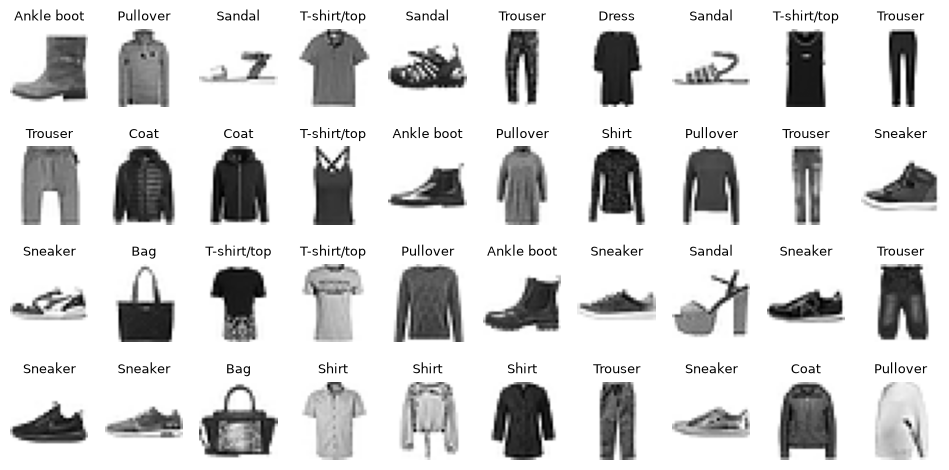

In [4]:
plt.figure(figsize=(12, 5.6))
for index in range(40):
    image, label = train_data[index]
    plt.subplot(4, 10, index + 1)
    plt.imshow(image.squeeze(0), cmap="binary")
    plt.axis("off")
    plt.title(class_names[label], fontsize=9)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig("p2_fashion_mnist_samples", tight_layout=False)
plt.show()

## 4. Build the model

In [5]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2), nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

def make_model():
    return ImageClassifier(1 * 28 * 28, N_HIDDEN1, N_HIDDEN2,
                           len(class_names)).to(device)

torch.manual_seed(SEED)
model = make_model()
xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=len(class_names)).to(device)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
trainable parameters: 266610


## 5. Train the model
`train()` extends the chapter's `train2()`. It records the training loss, the training accuracy for every epoch and every batch, and the validation accuracy.

In [6]:
def evaluate(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            metric.update(model(X_batch), y_batch)
    return metric.compute().item()

def train(model, optimizer, criterion, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": [],
               "batch_train_metrics": []}
    for epoch in range(n_epochs):
        model.train()
        metric.reset()
        total_loss = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()
            history["batch_train_metrics"].append(
                metric(y_pred, y_batch).item())  # batch value + running update
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate(model, valid_loader, metric))
        print(f"Epoch {epoch + 1:2d}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.4f}, "
              f"valid accuracy: {history['valid_metrics'][-1]:.4f}")
    return history

In [7]:
history = train(model, optimizer, xentropy, accuracy, train_loader,
                valid_loader, N_EPOCHS)

Epoch  1/20, train loss: 0.6060, train accuracy: 0.7814, valid accuracy: 0.8424


Epoch  2/20, train loss: 0.4061, train accuracy: 0.8496, valid accuracy: 0.8402


Epoch  3/20, train loss: 0.3630, train accuracy: 0.8661, valid accuracy: 0.8494


Epoch  4/20, train loss: 0.3355, train accuracy: 0.8768, valid accuracy: 0.8638


Epoch  5/20, train loss: 0.3154, train accuracy: 0.8829, valid accuracy: 0.8782


...

Epoch 16/20, train loss: 0.2078, train accuracy: 0.9196, valid accuracy: 0.8886


Epoch 17/20, train loss: 0.2033, train accuracy: 0.9233, valid accuracy: 0.8870


Epoch 18/20, train loss: 0.1991, train accuracy: 0.9230, valid accuracy: 0.8846


Epoch 19/20, train loss: 0.1916, train accuracy: 0.9266, valid accuracy: 0.8812


Epoch 20/20, train loss: 0.1876, train accuracy: 0.9286, valid accuracy: 0.8788


## 6. Plot the training accuracy
**Left:** training and validation accuracy for each epoch. The training accuracy is averaged *during* the epoch, so it is plotted half an epoch earlier, as in the chapter's learning curves.

**Right:** training accuracy per batch as a moving average, with the training loss per epoch on a second axis.

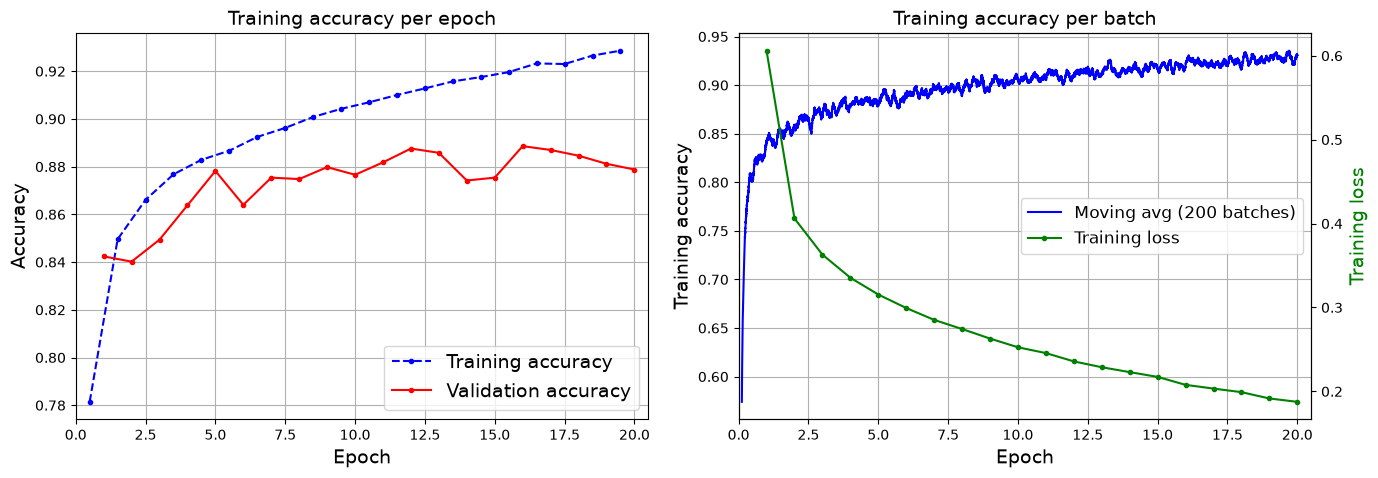

In [8]:
epochs = np.arange(1, N_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs - 0.5, history["train_metrics"], "b.--", label="Training accuracy")
ax1.plot(epochs, history["valid_metrics"], "r.-", label="Validation accuracy")
ax1.set(xlabel="Epoch", ylabel="Accuracy", title="Training accuracy per epoch",
        xlim=(0, N_EPOCHS + 0.5))
ax1.grid()
ax1.legend(loc="lower right")

batch_acc = np.array(history["batch_train_metrics"])
x_batches = np.arange(1, len(batch_acc) + 1) / (len(batch_acc) / N_EPOCHS)
window = min(200, len(batch_acc) // 4)
moving_avg = np.convolve(batch_acc, np.ones(window) / window, mode="valid")
ax2.plot(x_batches[window - 1:], moving_avg, "b-",
         label=f"Moving avg ({window} batches)")
ax2.set(xlabel="Epoch", ylabel="Training accuracy",
        title="Training accuracy per batch", xlim=(0, N_EPOCHS + 0.5))
ax2.grid()
ax3 = ax2.twinx()
ax3.plot(epochs, history["train_losses"], "g.-", label="Training loss")
ax3.set_ylabel("Training loss", color="g")
h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()
ax2.legend(h2 + h3, l2 + l3, loc="center right", fontsize=12)

save_fig("p2_training_accuracy_plot")
plt.show()

## 7. Evaluate on the test set and make predictions

Final training accuracy:   0.9286
Final validation accuracy: 0.8788
Test accuracy:             0.8824


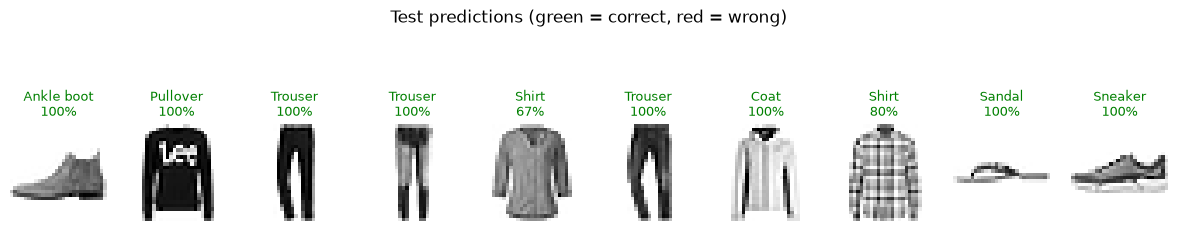

In [9]:
test_acc = evaluate(model, test_loader, accuracy)
print(f"Final training accuracy:   {history['train_metrics'][-1]:.4f}")
print(f"Final validation accuracy: {history['valid_metrics'][-1]:.4f}")
print(f"Test accuracy:             {test_acc:.4f}")

model.eval()
X_new, y_new = next(iter(test_loader))
with torch.no_grad():
    y_proba = F.softmax(model(X_new[:10].to(device)), dim=1).cpu()
y_pred = y_proba.argmax(dim=1)

plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_new[i].squeeze(0), cmap="binary")
    plt.axis("off")
    correct = y_pred[i] == y_new[i]
    plt.title(f"{class_names[y_pred[i]]}\n{y_proba[i].max():.0%}", fontsize=9,
              color="green" if correct else "red")
plt.suptitle("Test predictions (green = correct, red = wrong)", fontsize=12)
save_fig("p2_test_predictions")
plt.show()

## 8. Save and reload the model

In [10]:
Path(MODEL_PATH).parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)

loaded_model = make_model()
loaded_model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
loaded_acc = evaluate(loaded_model, test_loader, accuracy)
print(f"Saved to {MODEL_PATH}; reloaded model test accuracy: {loaded_acc:.4f}")

Saved to models/fashion_mnist_mlp.pt; reloaded model test accuracy: 0.8824


## 9. Self-test
Checks that the notebook ran correctly on your system. Each check prints ✅; if one fails, the cell raises an `AssertionError` that names the problem.

In [11]:
min_acc = 0.70 if QUICK_RUN else 0.85
checks = {
    "one history entry per epoch":
        all(len(history[k]) == N_EPOCHS
            for k in ("train_losses", "train_metrics", "valid_metrics")),
    "training loss decreased":
        history["train_losses"][-1] < history["train_losses"][0],
    "training accuracy increased":
        history["train_metrics"][-1] > history["train_metrics"][0],
    f"test accuracy >= {min_acc}": test_acc >= min_acc,
    "reloaded model gives identical test accuracy":
        abs(loaded_acc - test_acc) < 1e-6,
    "plots were saved":
        all((Path(IMAGES_DIR) / f).exists() for f in
            ("p2_fashion_mnist_samples.png", "p2_training_accuracy_plot.png",
             "p2_test_predictions.png")),
}
for name, passed in checks.items():
    print(("✅" if passed else "❌"), name)
failed = [name for name, passed in checks.items() if not passed]
assert not failed, f"Failed checks: {failed}"
print("\nAll checks passed.")

✅ one history entry per epoch
✅ training loss decreased
✅ training accuracy increased
✅ test accuracy >= 0.85
✅ reloaded model gives identical test accuracy
✅ plots were saved

All checks passed.
